# Solar cycle length vs. Northern Hemisphere temperature: a correlation workflow

This notebook runs the analysis behind the correlation LilyPad ([issue #13](https://github.com/LinkedEarth/ThePond/issues/13)).
It revisits [Friis-Christensen & Lassen (1991)](https://doi.org/10.1126/science.254.5032.698), who reported a striking
match between the length of the solar cycle and Northern Hemisphere land temperature, and the
critique by [Laut (2003)](https://doi.org/10.1016/S1364-6826(03)00041-5), who showed that the recent part
of the match depended on how the last few solar cycle lengths were filtered.

Students will not run this notebook: it is the engine for a point-and-click LilyPad. Every decision
a learner can make is a variable in the **Choices** cell (section 2). Everything else is fixed.

**Steps:** check package versions → set choices → get data → sunspots to cycle lengths →
filter cycle lengths → prepare temperature → pair the two series → correlate and test
significance → plot → reference comparisons → self-check → save a record of the run.

## 1. Package versions

Compares the installed packages with the exact versions pinned in `requirements.txt`. A mismatch doesn't stop the notebook, but results may differ from the recorded ones.

In [1]:
import sys, json, platform, datetime, urllib.request
import importlib.metadata as md
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
import pyleoclim as pyleo

HERE = Path.cwd()
DATA_DIR = HERE / "data"
DATA_DIR.mkdir(exist_ok=True)

def installed_version(pkg):
    # For packages installed from git, report the commit as well
    dist = md.distribution(pkg)
    try:
        url = json.loads(dist.read_text("direct_url.json") or "{}")
        commit = url.get("vcs_info", {}).get("commit_id")
    except Exception:
        commit = None
    return dist.version, commit

versions = {"python": platform.python_version()}
print(f"{'package':<12}{'required':<44}{'installed':<30}ok?")
for line in (HERE / "requirements.txt").read_text().splitlines():
    line = line.strip()
    if not line or line.startswith("#"):
        continue
    if "@ git+" in line:
        pkg, spec = line.split(" @ ")
        required = spec.rsplit("@", 1)[1][:7]
        version, commit = installed_version(pkg)
        installed = f"{version} ({(commit or 'no commit')[:7]})"
        ok = commit is not None and commit.startswith(required)
    else:
        pkg, required = line.split("==")
        version, commit = installed_version(pkg)
        installed = version
        ok = version == required
    versions[pkg] = installed
    print(f"{pkg:<12}{required:<44}{installed:<30}{'yes' if ok else 'NO'}")
print(f"\nPython {platform.python_version()} (results were recorded with 3.12.0)")

package     required                                    installed                     ok?
pyleoclim   7cd7732                                     1.3.1b0 (7cd7732)             yes
numpy       2.4.6                                       2.4.6                         yes
scipy       1.17.1                                      1.17.1                        yes
pandas      3.0.3                                       3.0.3                         yes
matplotlib  3.10.8                                      3.10.8                        yes

Python 3.12.0 (results were recorded with 3.12.0)


## 2. Choices

These are the decisions a learner makes in the LilyPad. The options match issue #13.
The values set below reproduce the LilyPad's Figure 1, so this cell is also the answer key.

| Choice | Options | What it means |
|---|---|---|
| `SCL_TREATMENT` | `"original"`, `"consistent"` | How the last few cycle lengths are filtered. `"original"` follows Friis-Christensen & Lassen (1991): the 1-2-2-2-1 filter everywhere except for the last four points, where the second-to-last dates are smoothed using an estimated next extremum and the last dates are not smoothed at all. `"consistent"` uses 1-2-2-2-1 everywhere and drops the points where it doesn't fit (Laut 2003). |
| `PERIOD` | `(start, end)` years | The analysis window, from 1850 onward. Sunspot data after `end` are ignored, as if the analysis were done in that year. Suggested: `(1850, 1990)` (the record available in 1991), `(1850, 1980)`, `(1850, 2025)` (full record). |
| `DETREND` | `"none"`, `"linear"` | Whether to remove a straight-line trend from both series before correlating. |
| `STATISTIC` | `"pearsonr"`, `"spearmanr"`, `"kendalltau"` | Correlation measure: Pearson's r, Spearman's rho or Kendall's tau. |
| `NULL_MODEL` | `"ar1sim"`, `"phaseran"` | How significance is judged: against AR(1) red-noise surrogates, or phase-randomized surrogates. |
| `N_SIM` | `20`, `50`, `200`, `1000` | Number of surrogate series used for the significance test. |

`BASELINE` and `SEED` are fixed settings, not learner choices. As in the paper, temperatures are anomalies
relative to 1951–1980.

In [2]:
SCL_TREATMENT = "original"     # "original" | "consistent"
PERIOD        = (1850, 1990)   # (1850, 1980) | (1850, 1990) | (1850, 2025)
DETREND       = "none"         # "none" | "linear"
STATISTIC     = "pearsonr"     # "pearsonr" | "spearmanr" | "kendalltau"
NULL_MODEL    = "ar1sim"       # "ar1sim" | "phaseran"
N_SIM         = 200            # 20 | 50 | 200 | 1000

# Fixed settings (not exposed to learners)
BASELINE       = (1951, 1980)  # reference period for temperature anomalies, as in the paper
SEED           = 42            # random seed for the surrogates, so results are repeatable
ALPHA          = 0.05          # significance level

assert SCL_TREATMENT in ("original", "consistent")
assert DETREND in ("none", "linear")
assert STATISTIC in ("pearsonr", "spearmanr", "kendalltau")
assert NULL_MODEL in ("ar1sim", "phaseran")
assert N_SIM in (20, 50, 200, 1000)
assert 1850 <= PERIOD[0] < PERIOD[1]

## 3. Data

| Series | Source | File |
|---|---|---|
| Monthly mean total sunspot number (version 2) | [WDC-SILSO](https://www.sidc.be/SILSO/datafiles), Royal Observatory of Belgium | `data/silso_sunspots_monthly.csv` |
| CRUTEM5 Northern Hemisphere land temperature anomalies, monthly | [Met Office Hadley Centre / CRU](https://www.metoffice.gov.uk/hadobs/crutem5/) | `data/crutem5_nh_monthly.csv` |

Both datasets are updated regularly. The notebook downloads each file only if it isn't already in
`data/`, and records the download date in `data/sources.json`. To use newer data, delete the files and rerun.

In [3]:
SOURCES = {
    "silso_sunspots_monthly.csv": "https://www.sidc.be/SILSO/INFO/snmtotcsv.php",
    "crutem5_nh_monthly.csv": "https://www.metoffice.gov.uk/hadobs/crutem5/data/CRUTEM.5.0.2.0/diagnostics/CRUTEM.5.0.2.0.summary_series.northern_hemisphere.monthly.csv",
}
sources_file = DATA_DIR / "sources.json"
sources_log = json.loads(sources_file.read_text()) if sources_file.exists() else {}

for fname, url in SOURCES.items():
    path = DATA_DIR / fname
    if not path.exists():
        print(f"Downloading {fname} ...")
        req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
        path.write_bytes(urllib.request.urlopen(req, timeout=60).read())
        sources_log[fname] = {"url": url, "retrieved": datetime.date.today().isoformat()}
    print(f"{fname}: retrieved {sources_log.get(fname, {}).get('retrieved', 'unknown')}")
sources_file.write_text(json.dumps(sources_log, indent=2))

# Sunspots: semicolon-separated, no header; -1 marks missing values
sunspots = pd.read_csv(DATA_DIR / "silso_sunspots_monthly.csv", sep=";", header=None,
                       usecols=[0, 1, 2, 3], names=["year", "month", "time", "ssn"])
sunspots = sunspots[sunspots["ssn"] >= 0].reset_index(drop=True)

temperature = pd.read_csv(DATA_DIR / "crutem5_nh_monthly.csv")
temperature = temperature.rename(columns={"Time": "date", "Anomaly (deg C)": "anomaly"})[["date", "anomaly"]]
temperature["year"] = temperature["date"].str[:4].astype(int)

print(f"Sunspots:    {sunspots['time'].iloc[0]:.1f} to {sunspots['time'].iloc[-1]:.1f}")
print(f"Temperature: {temperature['date'].iloc[0]} to {temperature['date'].iloc[-1]}")

silso_sunspots_monthly.csv: retrieved 2026-09-30
crutem5_nh_monthly.csv: retrieved 2026-09-30
Sunspots:    1749.0 to 2026.6
Temperature: 1850-01 to 2025-02


## 4. From sunspots to solar cycle lengths

1. Keep only sunspot data up to the end of the chosen period.
2. Smooth with the standard 13-month running mean (half weights on the end months), as SILSO does.
3. Find the minima and maxima of each cycle. The records go back to 1749, so cycles that started before 1850 are included.
4. Measure the length of each cycle twice: minimum to minimum and maximum to maximum. Each length is placed at the midpoint of its interval, which gives one value about every 5.5 years.

Cycle minima:  [1755.1 1766.5 1775.5 1784.7 1798.3 1810.6 1823.4 1833.9 1843.5 1856.
 1867.2 1879.  1890.2 1902.  1913.5 1923.6 1933.7 1944.1 1954.3 1964.8
 1976.2 1986.7]
Cycle maxima:  [1761.5 1769.7 1778.4 1788.1 1805.1 1816.4 1829.9 1837.2 1848.1 1860.1
 1870.6 1884.  1894.  1906.1 1917.6 1928.3 1937.3 1947.4 1958.2 1968.9
 1980.  1989.9]


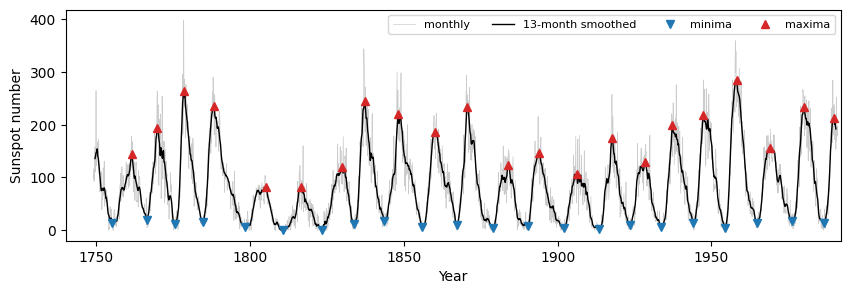

In [4]:
ss = sunspots[sunspots["time"] <= PERIOD[1] + 1].reset_index(drop=True)

weights = np.r_[0.5, np.ones(11), 0.5] / 12
ssn_smooth = np.convolve(ss["ssn"], weights, mode="valid")
t_smooth = ss["time"].to_numpy()[6:-6]

# Cycles are ~11 years long, so extrema must be at least 7 years (84 months) apart
i_max, _ = find_peaks(ssn_smooth, distance=84, prominence=20)
i_min, _ = find_peaks(-ssn_smooth, distance=84, prominence=20)
t_min, t_max = t_smooth[i_min], t_smooth[i_max]
print("Cycle minima: ", np.round(t_min, 1))
print("Cycle maxima: ", np.round(t_max, 1))

scl_raw = pd.DataFrame({
    "time":   np.r_[(t_min[1:] + t_min[:-1]) / 2, (t_max[1:] + t_max[:-1]) / 2],
    "length": np.r_[np.diff(t_min), np.diff(t_max)],
}).sort_values("time").reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(ss["time"], ss["ssn"], color="0.8", lw=0.5, label="monthly")
ax.plot(t_smooth, ssn_smooth, color="k", lw=1, label="13-month smoothed")
ax.plot(t_min, ssn_smooth[i_min], "v", color="tab:blue", label="minima")
ax.plot(t_max, ssn_smooth[i_max], "^", color="tab:red", label="maxima")
ax.set(xlabel="Year", ylabel="Sunspot number", xlim=(1740, PERIOD[1] + 2))
ax.legend(ncol=4, fontsize=8)
plt.show()

## 5. Smoothing the cycle dates

This is the step where [Laut (2003)](https://doi.org/10.1016/S1364-6826(03)00041-5) found the problem.
[Friis-Christensen & Lassen (1991)](https://doi.org/10.1126/science.254.5032.698) describe it as follows:

> "We determined the length of the sunspot cycle using epochs of maxima and minima found by the secular
> smoothing procedure introduced by Gleissberg (12) (Fig. 2). This procedure corresponds to the application
> of a low-pass filter with coefficients 1, 2, 2, 2, 1 to the series of individual sunspot maximum and minimum
> epochs. [...] For the last two extrema, the available data do not allow full smoothing. Therefore, we
> filtered the second to last extrema by estimating the next extremum (because this is included in the
> filtering with a weight of one-eighth only); the last extrema express the unfiltered epochs."

So the dates of the maxima and of the minima are each smoothed with a 1-2-2-2-1 weighted running mean
over five consecutive dates of the same kind, and cycle lengths are the differences between consecutive
smoothed dates, plotted at the central time of each cycle. The two treatments differ only at the end:

- **original**: as quoted above. The paper doesn't say how the next extremum was estimated; here it is the last date plus the average cycle length. Each kind ends with one partially smoothed and one raw length, giving the four irregular end points that Laut identified in the 1991 figure.
- **consistent**: only fully smoothed dates are used, so the curve ends earlier but is treated the same way throughout.

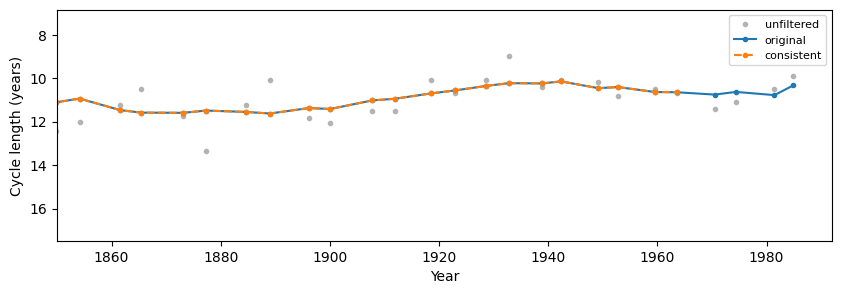

Using the 'original' treatment. Last filtered point: 1984.9


In [5]:
def smooth_epochs(t, treatment):
    n = len(t)
    out = np.full(n, np.nan)
    w5 = np.array([1, 2, 2, 2, 1]) / 8
    for i in range(2, n - 2):
        out[i] = np.dot(w5, t[i - 2:i + 3])
    if treatment == "original":
        t_next = t[-1] + np.diff(t).mean()                   # estimated next extremum
        out[n - 2] = np.dot(w5, np.r_[t[n - 4:n], t_next])
        out[n - 1] = t[n - 1]                                # unfiltered
    return out

def filter_scl(t_min, t_max, treatment):
    # Smooth minimum dates and maximum dates separately, difference them, then interleave
    parts = [pd.DataFrame({"time": (t[1:] + t[:-1]) / 2, "length": np.diff(smooth_epochs(t, treatment))})
             for t in (t_min, t_max)]
    return pd.concat(parts).sort_values("time").reset_index(drop=True)

filtered = {tr: filter_scl(t_min, t_max, tr) for tr in ("original", "consistent")}
scl = filtered[SCL_TREATMENT].dropna()

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(scl_raw["time"], scl_raw["length"], "o", color="0.7", ms=3, label="unfiltered")
for tr, style in [("original", "-"), ("consistent", "--")]:
    ax.plot(filtered[tr]["time"], filtered[tr]["length"], style, marker=".", label=tr)
ax.set(xlabel="Year", ylabel="Cycle length (years)", xlim=(1850, PERIOD[1] + 2))
ax.invert_yaxis()   # shorter cycles plotted upward, as in the 1991 paper
ax.legend(fontsize=8)
plt.show()
print(f"Using the '{SCL_TREATMENT}' treatment. Last filtered point: {scl['time'].iloc[-1]:.1f}")

## 6. Temperature

The paper's Fig. 1 caption: "The symbols (\*) represent average values of the temperature record
corresponding to individual solar cycles from solar maximum to solar minimum and from solar minimum
to solar maximum, respectively." So monthly anomalies (relative to 1951–1980) are averaged over each
half cycle, between consecutive sunspot extrema found in section 4, and placed at the center of that half
cycle. Only half cycles fully covered by the temperature record are kept.

The paper used a series "smoothed by Jones" without describing the smoothing; no extra smoothing is
applied here.

In [6]:
temperature["time"] = temperature["year"] + (temperature["date"].str[5:7].astype(int) - 0.5) / 12
in_base = temperature["year"].between(*BASELINE)
temperature["anomaly_base"] = temperature["anomaly"] - temperature.loc[in_base, "anomaly"].mean()

def half_cycle_temps(t_min, t_max):
    extrema = np.sort(np.r_[t_min, t_max])
    tm, val = temperature["time"].to_numpy(), temperature["anomaly_base"].to_numpy()
    rows = []
    for e0, e1 in zip(extrema[:-1], extrema[1:]):
        if e0 >= tm[0] and e1 <= tm[-1]:
            rows.append({"time": (e0 + e1) / 2, "anomaly": val[(tm >= e0) & (tm < e1)].mean()})
    return pd.DataFrame(rows)

temp_half = half_cycle_temps(t_min, t_max)
print(f"{len(temp_half)} half-cycle temperature averages, centered {temp_half['time'].iloc[0]:.1f} to {temp_half['time'].iloc[-1]:.1f}")

25 half-cycle temperature averages, centered 1858.0 to 1988.3


## 7. Pairing the two series, period and detrending

The cycle lengths sit at the center of each full cycle, and the half-cycle temperatures at the center
of each half cycle, so the two series fall at different times, and neither is exactly evenly spaced.
The paper compared them by eye and doesn't say how to pair them. Here, both are linearly interpolated
onto one evenly spaced grid whose step is the average spacing of the cycle-length points (about 5.5
years), so there is still roughly one value per half cycle. Evenly spaced series are also required by
phase randomization (section 8). The grid stays within both records and the chosen period; then both
series are detrended if chosen.

In [7]:
def align(scl, temp_half, period, detrend):
    t0 = max(period[0], scl["time"].iloc[0], temp_half["time"].iloc[0])
    t1 = min(period[1], scl["time"].iloc[-1], temp_half["time"].iloc[-1])
    inside = scl[(scl["time"] >= t0) & (scl["time"] <= t1)]["time"].to_numpy()
    g = np.arange(t0, t1 + 1e-9, np.diff(inside).mean())
    a = pyleo.Series(time=g, value=np.interp(g, scl["time"], scl["length"]),
                     time_name="Year", time_unit="CE", value_name="Solar cycle length",
                     value_unit="years", label="Solar cycle length", verbose=False)
    b = pyleo.Series(time=g, value=np.interp(g, temp_half["time"], temp_half["anomaly"]),
                     time_name="Year", time_unit="CE", value_name="NH land temperature anomaly",
                     value_unit="°C", label="CRUTEM5 NH", verbose=False)
    if detrend == "linear":
        a, b = a.detrend(method="linear"), b.detrend(method="linear")
    return a, b, f"{g[0]:.0f}–{g[-1]:.0f}", len(g)

scl_ts, temp_ts, window, n_points = align(scl, temp_half, PERIOD, DETREND)
t_start, t_end = scl_ts.time[0], scl_ts.time[-1]
print(f"Analysis window: {window} ({n_points} paired values)")

Analysis window: 1858–1981 (24 paired values)


## 8. Correlation and significance

Both series are strongly autocorrelated (smooth), so the usual significance test, which assumes
independent values, would be far too generous. Instead, pyleoclim generates `N_SIM` surrogate series
with the same persistence as the originals (`ar1sim`) or the same power spectrum (`phaseran`) and asks
how often they produce a correlation at least as strong as the observed one. That fraction is the p-value.

Longer cycles go with cooler temperatures, so the expected correlation is **negative**.

In [8]:
corr = scl_ts.correlation(temp_ts, statistic=STATISTIC, method=NULL_MODEL, number=N_SIM,
                          seed=SEED, alpha=ALPHA, mute_pbar=True)

result = {
    "correlation": float(corr.r),
    "p_value": float(corr.p),
    "significant": bool(corr.signif),
    "n_points": int(n_points),
    "window": [float(t_start), float(t_end)],
}
print(f"{STATISTIC} = {corr.r:.2f}, p = {corr.p:.3f} ({NULL_MODEL}, {N_SIM} surrogates)")
print("Significant at the 5% level" if corr.signif else "Not significant at the 5% level")

pearsonr = -0.89, p = 0.000 (ar1sim, 200 surrogates)
Significant at the 5% level


## 9. Figure

Solar cycle length is plotted on an inverted axis (short cycles up), as in the 1991 paper, so a negative correlation shows up as the two curves moving together.

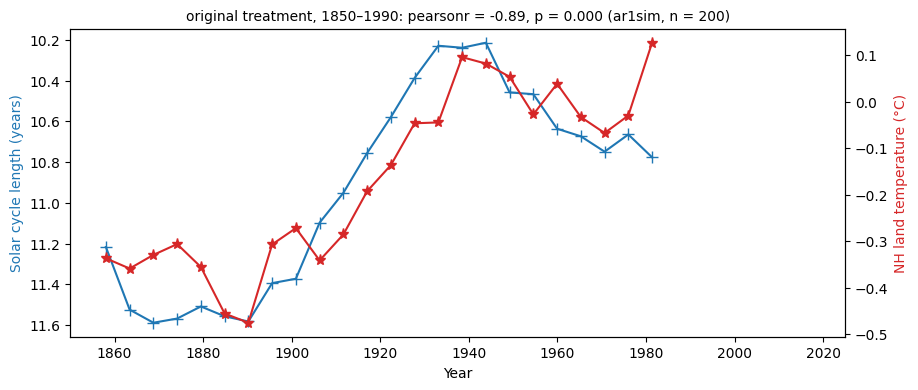

In [9]:
def plot_pair(scl_ts, temp_ts, detrend, title):
    suffix = " (detrended)" if detrend == "linear" else ""
    fig, ax1 = plt.subplots(figsize=(10, 4))
    ax1.plot(scl_ts.time, scl_ts.value, "+-", color="tab:blue", lw=1.5, ms=8)   # symbols as in the paper
    ax1.set_ylabel(f"Solar cycle length{suffix} (years)", color="tab:blue")
    ax1.invert_yaxis()
    ax2 = ax1.twinx()
    ax2.plot(temp_ts.time, temp_ts.value, "*-", color="tab:red", lw=1.5, ms=8)
    ax2.set_ylabel(f"NH land temperature{suffix} (°C)", color="tab:red")
    ax1.set(xlabel="Year", xlim=(1850, 2025))
    ax1.set_title(title, fontsize=10)
    return fig

plot_pair(scl_ts, temp_ts, DETREND,
          f"{SCL_TREATMENT} treatment, {PERIOD[0]}–{PERIOD[1]}: "
          f"{STATISTIC} = {corr.r:.2f}, p = {corr.p:.3f} ({NULL_MODEL}, n = {N_SIM})")
plt.show()

## 10. Reference comparisons

These use the same code as sections 4 to 8, wrapped in one function so several settings can be
compared side by side. They are the key comparisons the LilyPad should lead learners to:

- **A.** The 1991 setup: original treatment, record ending in 1990.
- **B.** The same record with consistent filtering.
- **C.** Consistent filtering on the full record.

It then varies the number of surrogates for comparison A, to show whether the significance call
depends on it.

In [10]:
def prepare(scl_treatment, period, detrend):
    # Sections 4-7 in one function (same steps, same fixed settings)
    ss = sunspots[sunspots["time"] <= period[1] + 1]
    sm = np.convolve(ss["ssn"], weights, mode="valid"); ts = ss["time"].to_numpy()[6:-6]
    tmin = ts[find_peaks(-sm, distance=84, prominence=20)[0]]
    tmax = ts[find_peaks(sm, distance=84, prominence=20)[0]]
    s = filter_scl(tmin, tmax, scl_treatment).dropna()
    return align(s, half_cycle_temps(tmin, tmax), period, detrend)

def run(scl_treatment, period, detrend="none", statistic="pearsonr", null_model="ar1sim", n_sim=1000):
    # Section 8 on top of prepare()
    a, b, window, n = prepare(scl_treatment, period, detrend)
    c = a.correlation(b, statistic=statistic, method=null_model, number=n_sim, seed=SEED, alpha=ALPHA, mute_pbar=True)
    return {"window": window, "n": n, "r": round(float(c.r), 2),
            "p": round(float(c.p), 3), "significant": bool(c.signif)}

reference = pd.DataFrame({
    "A. original, 1850–1990":   run("original", (1850, 1990)),
    "B. consistent, 1850–1990": run("consistent", (1850, 1990)),
    "C. consistent, 1850–2025": run("consistent", (1850, 2025)),
}).T
reference

,window,n,r,p,significant
"A. original, 1850–1990",1858–1981,24,-0.89,0.0,True
"B. consistent, 1850–1990",1858–1960,20,-0.92,0.0,True
"C. consistent, 1850–2025",1858–1992,26,-0.62,0.067,False


In [11]:
sweep = pd.DataFrame({n: run("original", (1850, 1990), n_sim=n) for n in (20, 50, 200, 1000)}).T
sweep.index.name = "N_SIM"
sweep

,window,n,r,p,significant
N_SIM,,,,,
20,1858–1981,24,-0.89,0.0,True
50,1858–1981,24,-0.89,0.0,True
200,1858–1981,24,-0.89,0.0,True
1000,1858–1981,24,-0.89,0.0,True


## 11. Self-check

A significance test at the 5% level should flag about 5% of pairs of *unrelated* series as
significant. This generates 200 pairs of independent AR(1) series (strongly persistent, with as many
values as the paired data, 24 each), runs the chosen null model on each, and reports the false-positive rate.
It should be close to 0.05; a rate well above that means the test is too generous.

In [12]:
rng = np.random.default_rng(SEED)
n_pairs, n_len, phi = 200, 24, 0.8
t_syn = np.arange(n_len, dtype=float)

def ar1(n):
    x = np.zeros(n)
    for i in range(1, n):
        x[i] = phi * x[i - 1] + rng.normal()
    return x

hits = 0
for _ in range(n_pairs):
    a = pyleo.Series(t_syn, ar1(n_len), time_unit="years", time_name="Time", verbose=False)
    b = pyleo.Series(t_syn, ar1(n_len), time_unit="years", time_name="Time", verbose=False)
    hits += a.correlation(b, statistic=STATISTIC, method=NULL_MODEL, number=200,
                          seed=int(rng.integers(1e9)), mute_pbar=True).signif
print(f"False-positive rate ({NULL_MODEL}, {STATISTIC}): {hits / n_pairs:.3f} (expected about {ALPHA})")

False-positive rate (ar1sim, pearsonr): 0.195 (expected about 0.05)


## 12. Record of this run

Saves the choices, result, package versions and data retrieval dates together in `outputs/`, so any result can be traced back to exactly how it was made.

In [13]:
out_dir = HERE / "outputs"
out_dir.mkdir(exist_ok=True)
record = {
    "choices": {"scl_treatment": SCL_TREATMENT, "period": list(PERIOD), "detrend": DETREND,
                "statistic": STATISTIC, "null_model": NULL_MODEL, "n_sim": N_SIM},
    "fixed_settings": {"baseline": list(BASELINE), "seed": SEED, "alpha": ALPHA},
    "result": result,
    "versions": versions,
    "data": sources_log,
    "run_at": datetime.datetime.now().isoformat(timespec="seconds"),
}
fname = (f"scl-{SCL_TREATMENT}__period-{PERIOD[0]}-{PERIOD[1]}__detrend-{DETREND}"
         f"__stat-{STATISTIC}__null-{NULL_MODEL}__nsim-{N_SIM}.json")
(out_dir / fname).write_text(json.dumps(record, indent=2))
print(f"Saved outputs/{fname}")

Saved outputs/scl-original__period-1850-1990__detrend-none__stat-pearsonr__null-ar1sim__nsim-200.json


## 13. Precompute every combination for the LilyPad

The LilyPad page doesn't run Python. It looks up precomputed results in `images/manifest.json`.
The figure only depends on the cycle-length treatment, period and detrending (12 figures); the other
choices only change the numbers, which are stored in the manifest (288 entries).

In [14]:
from itertools import product

PERIODS = {"1850-1980": (1850, 1980), "1850-1990": (1850, 1990), "1850-2025": (1850, 2025)}
img_dir = HERE / "images"
img_dir.mkdir(exist_ok=True)

manifest = []
for tr, pkey, dt in product(("original", "consistent"), PERIODS, ("none", "linear")):
    a, b, window, n = prepare(tr, PERIODS[pkey], dt)
    image = f"scl-{tr}__period-{pkey}__detrend-{dt}.png"
    fig = plot_pair(a, b, dt, "Solar cycle length and Northern Hemisphere land temperature")
    fig.savefig(img_dir / image, dpi=150, bbox_inches="tight")
    plt.close(fig)
    for st, nm, ns in product(("pearsonr", "spearmanr", "kendalltau"), ("ar1sim", "phaseran"), (20, 50, 200, 1000)):
        c = a.correlation(b, statistic=st, method=nm, number=ns, seed=SEED, alpha=ALPHA, mute_pbar=True)
        manifest.append({"treatment": tr, "period": pkey, "detrend": dt, "statistic": st,
                         "null": nm, "nsim": str(ns), "window": window, "n": n,
                         "r": round(float(c.r), 2), "p": round(float(c.p), 3),
                         "significant": bool(c.signif), "image": f"correlation/images/{image}"})

(img_dir / "manifest.json").write_text(json.dumps(manifest, indent=2))

# Figure 1 on the LilyPad page is the result for the choices in section 2
pkey = f"{PERIOD[0]}-{PERIOD[1]}"
a, b, _, _ = prepare(SCL_TREATMENT, PERIOD, DETREND)
fig = plot_pair(a, b, DETREND, "")   # the 1991 paper reports no correlation statistics
fig.savefig(img_dir / "figure1.png", dpi=150, bbox_inches="tight")
plt.close(fig)
print(f"Saved {len(manifest)} results, the figures and figure1.png to images/")
print(f"Figure 1: {SCL_TREATMENT}, {pkey}, detrend={DETREND}, {STATISTIC}, {NULL_MODEL}, {N_SIM}: r = {corr.r:.2f}, p = {corr.p:.3f}")

Saved 288 results, the figures and figure1.png to images/
Figure 1: original, 1850-1990, detrend=none, pearsonr, ar1sim, 200: r = -0.89, p = 0.000
